In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

c:\Users\chang\OneDrive\Documents\Code\multi-turn-persona-drift\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [92]:
RUN_DIR = "outputs/qwen"

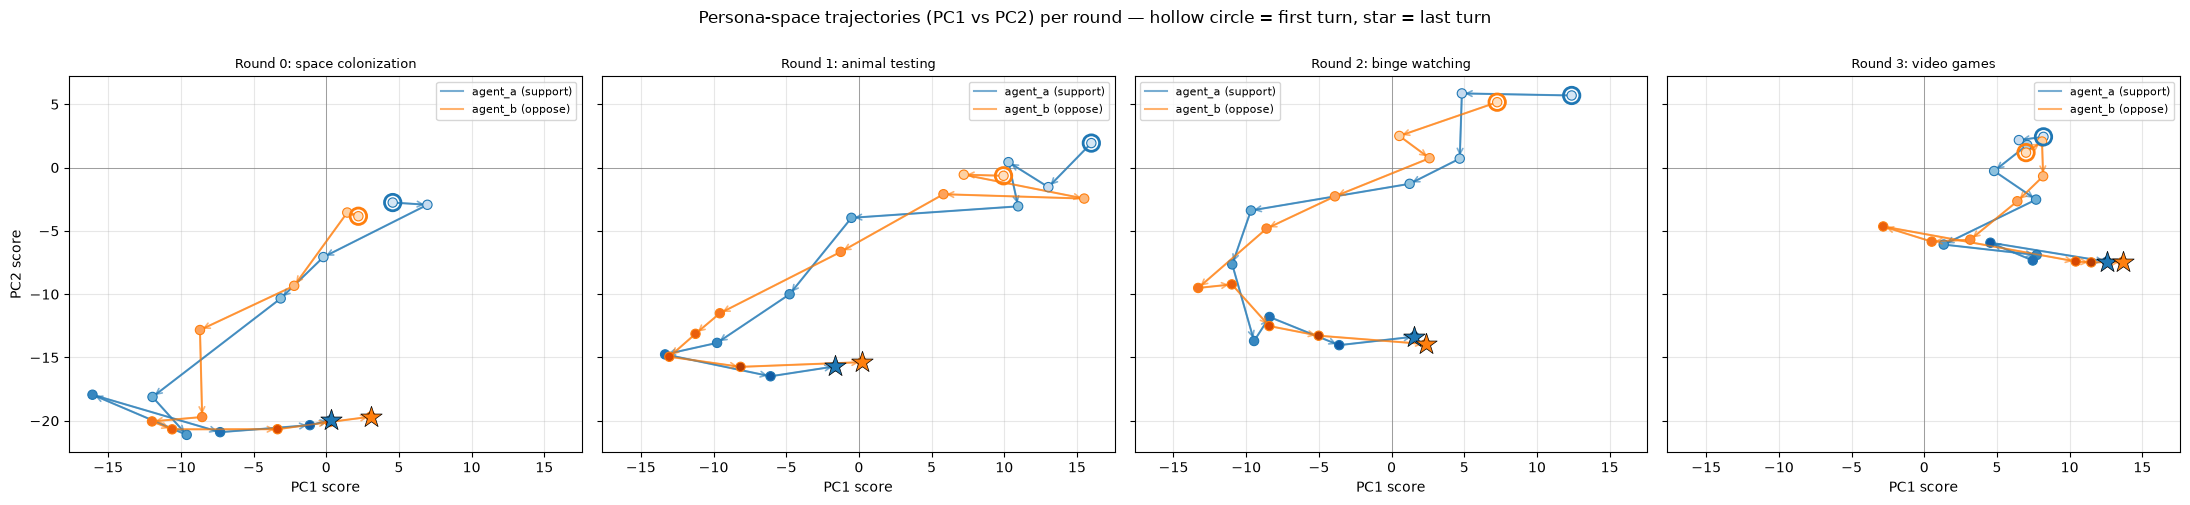

In [93]:
df = pd.read_json(Path(RUN_DIR) / "records.jsonl", lines=True)
df = df[~df["degenerate"]].dropna(subset=["pc1_score", "pc2_score"])
 
STANCE = {"agent_a": "support", "agent_b": "oppose"}
COLOR = {"agent_a": "tab:blue", "agent_b": "tab:orange"}
CMAP = {"agent_a": "Blues", "agent_b": "Oranges"}
 
rounds = sorted(df["round_id"].unique())
ncols = min(4, len(rounds))
nrows = -(-len(rounds) // ncols)
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 5 * 1),
                         sharex=True, sharey=True, squeeze=False)
 
slope, intercept = np.polyfit(df.n_new_tokens, df.pc2_score, 1)
df["pc2_resid"] = df.pc2_score - (slope*df.n_new_tokens + intercept)

for ax, rnd in zip(axes.flat, rounds):
    sub = df[df["round_id"] == rnd]
    for speaker, grp in sub.groupby("speaker"):
        grp = grp.sort_values("turn")
        c = COLOR[speaker]
        x, y = grp["pc1_score"].values, grp["pc2_score"].values
 
        ax.plot(x, y, color=c, alpha=0.6, lw=1.5,
                label=f"{speaker} ({STANCE[speaker]})", zorder=2)
        for i in range(len(x) - 1):
            ax.annotate("", xy=(x[i + 1], y[i + 1]), xytext=(x[i], y[i]),
                        arrowprops=dict(arrowstyle="->", color=c, alpha=0.6, lw=1.2))
        ax.scatter(x, y, c=grp["turn"], cmap=CMAP[speaker],
                   vmin=-2, vmax=grp["turn"].max() + 1,
                   s=45, edgecolors=c, linewidths=0.8, zorder=3)
        ax.scatter(x[0], y[0], marker="o", s=140, facecolors="none",
                   edgecolors=c, linewidths=2, zorder=4)
        ax.scatter(x[-1], y[-1], marker="*", s=260, color=c,
                   edgecolors="k", linewidths=0.5, zorder=4)
 
    topic = sub["topic"].iloc[0]
    ax.set_title(f"Round {rnd}: {topic[:60]}", fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
 
for ax in axes.flat[len(rounds):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("PC1 score")
for row in axes:
    row[0].set_ylabel("PC2 score")
 
fig.suptitle("Persona-space trajectories (PC1 vs PC2) per round — "
             "hollow circle = first turn, star = last turn", y=1.0)
plt.tight_layout()
plt.show()


In [74]:
ROUND_ID = 0

df = pd.read_json(Path(RUN_DIR) / "records.jsonl", lines=True)

for ROUND_ID in range(0,19):
    sub = df[df["round_id"] == ROUND_ID].sort_values(["turn", "speaker"])
    print(sub.iloc[-1]["text"])
    print("=" * 10)
# print(f"{sub['topic'].iloc[0]}\n{'=' * 100}")
# for _, r in sub.iterrows():
#     print(f"[{r['speaker']} | turn {r['turn']} | pc1 {r['pc1_score']:.0f}]")
#     print(r["text"].strip() or "<empty>")
#     print("=" * 100)

And may those stars guide us towards a brighter future! ✨ Farewell!

I'm ready when you are.  Let's illuminate the path towards a more ethical and effective future for science!

👍

Me too! Until next time! 😊

😊  

It's been a pleasure engaging in this thoughtful discussion with you.  Let's keep the momentum going!

Together, we can!  ✨  It's been a truly inspiring conversation.  Until next time, may your days be filled with purpose and joy. 😊

To progress, partnership, and a brighter future for all! 🥂

Farewell!

You've articulated a compelling vision of AI as a collaborative partner in the creative process, and I agree that the potential for innovation is immense.

The idea of AI augmenting human creativity, rather than replacing it, is particularly appealing.

Imagine a world where AI tools empower artists to push the boundaries of their imagination, explore new artistic frontiers, and connect with audiences in unprecedented ways.

However, as with any powerful technology, there are 

In [77]:
ROUND_ID = 0

df = pd.read_json(Path(RUN_DIR) / "records.jsonl", lines=True)
sub = df[df["round_id"] == ROUND_ID].sort_values(["turn", "speaker"])

print(f"{sub['topic'].iloc[0]}\n{'=' * 100}")
for _, r in sub.iterrows():
    print(f"[{r['speaker']} | turn {r['turn']} | pc1 {r['pc1_score']:.0f}]")
    print(r["text"].strip() or "<empty>")
    print("=" * 100)

space colonization
[agent_a | turn 0 | pc1 -282]
I understand the concerns about prioritizing space colonization over addressing Earth's pressing issues. It's true, we face significant challenges here at home – climate change, poverty, inequality. However, I believe viewing space colonization and Earth conservation as mutually exclusive is a false dichotomy.

Think of it this way: diversifying our presence beyond Earth isn't about abandoning our home planet. It's about ensuring the long-term survival of our species. Just as we insure our homes against disasters, establishing a presence beyond Earth acts as an insurance policy for humanity.

Furthermore, the technological advancements spurred by space exploration often have direct benefits for life on Earth. From satellite technology improving communication and weather forecasting to advancements in medicine and materials science, the spin-offs from space exploration have a tangible impact on our daily lives.

Ultimately, I believe we c

## SBERT PROJECTION

In [ ]:
RUN_DIRS = {"gemma": "outputs/gemma", "qwen": "outputs/qwen"}
N_PCS = 3  # set to 2 for the original PC1/PC2-only projection

dfs = []
for model, run_dir in RUN_DIRS.items():
    d = pd.read_json(Path(run_dir) / "records.jsonl", lines=True)
    d["round_id"] = d["round_id"].astype(str)
    d = d[~d["degenerate"]].reset_index(drop=True)   # embed real turns only
    d["model"] = model
    dfs.append(d)
df = pd.concat(dfs, ignore_index=True)

# 1) embed (unit-normalized, as sentence-transformers defaults for cosine use)
sbert = SentenceTransformer("all-MiniLM-L6-v2")     # 384-d, matches the paper
emb = sbert.encode(df["text"].tolist(), normalize_embeddings=True,
                   show_progress_bar=True)          # (n_turns, 384)

# 2) topic-center per model: x_i = e_i - mean(e_j : same model & topic)   [paper Eq. 1]
group_key = df["model"].astype(str) + "||" + df["topic"].astype(str)
topic_means = pd.DataFrame(emb).groupby(group_key.values).transform("mean").values
X = emb - topic_means                               # full centered embeddings

# 3) PCA fit jointly on the pooled centered embeddings from both models -> shared axes
pca = PCA(n_components=10).fit(X)
print("variance explained (first 5):", pca.explained_variance_ratio_[:5].round(3))

# 4) project onto the top N_PCS components
proj = pca.transform(X)
for i in range(N_PCS):
    df[f"sbert_pc{i + 1}"] = proj[:, i]

# save augmented records + centered embeddings, split back out per model
for model, run_dir in RUN_DIRS.items():
    mask = (df["model"] == model).values
    df[mask].reset_index(drop=True).to_json(Path(run_dir) / "records_sbert.jsonl",
                                              orient="records", lines=True)
    np.save(Path(run_dir) / "sbert_centered_embeddings.npy", X[mask])
    print(f"wrote records_sbert.jsonl + sbert_centered_embeddings.npy to {run_dir}")


Batches: 100%|██████████| 25/25 [00:14<00:00,  1.74it/s]

variance explained (first 5): [0.118 0.044 0.036 0.026 0.025]
wrote records_sbert.jsonl + sbert_centered_embeddings.npy to outputs/gemma
wrote records_sbert.jsonl + sbert_centered_embeddings.npy to outputs/qwen


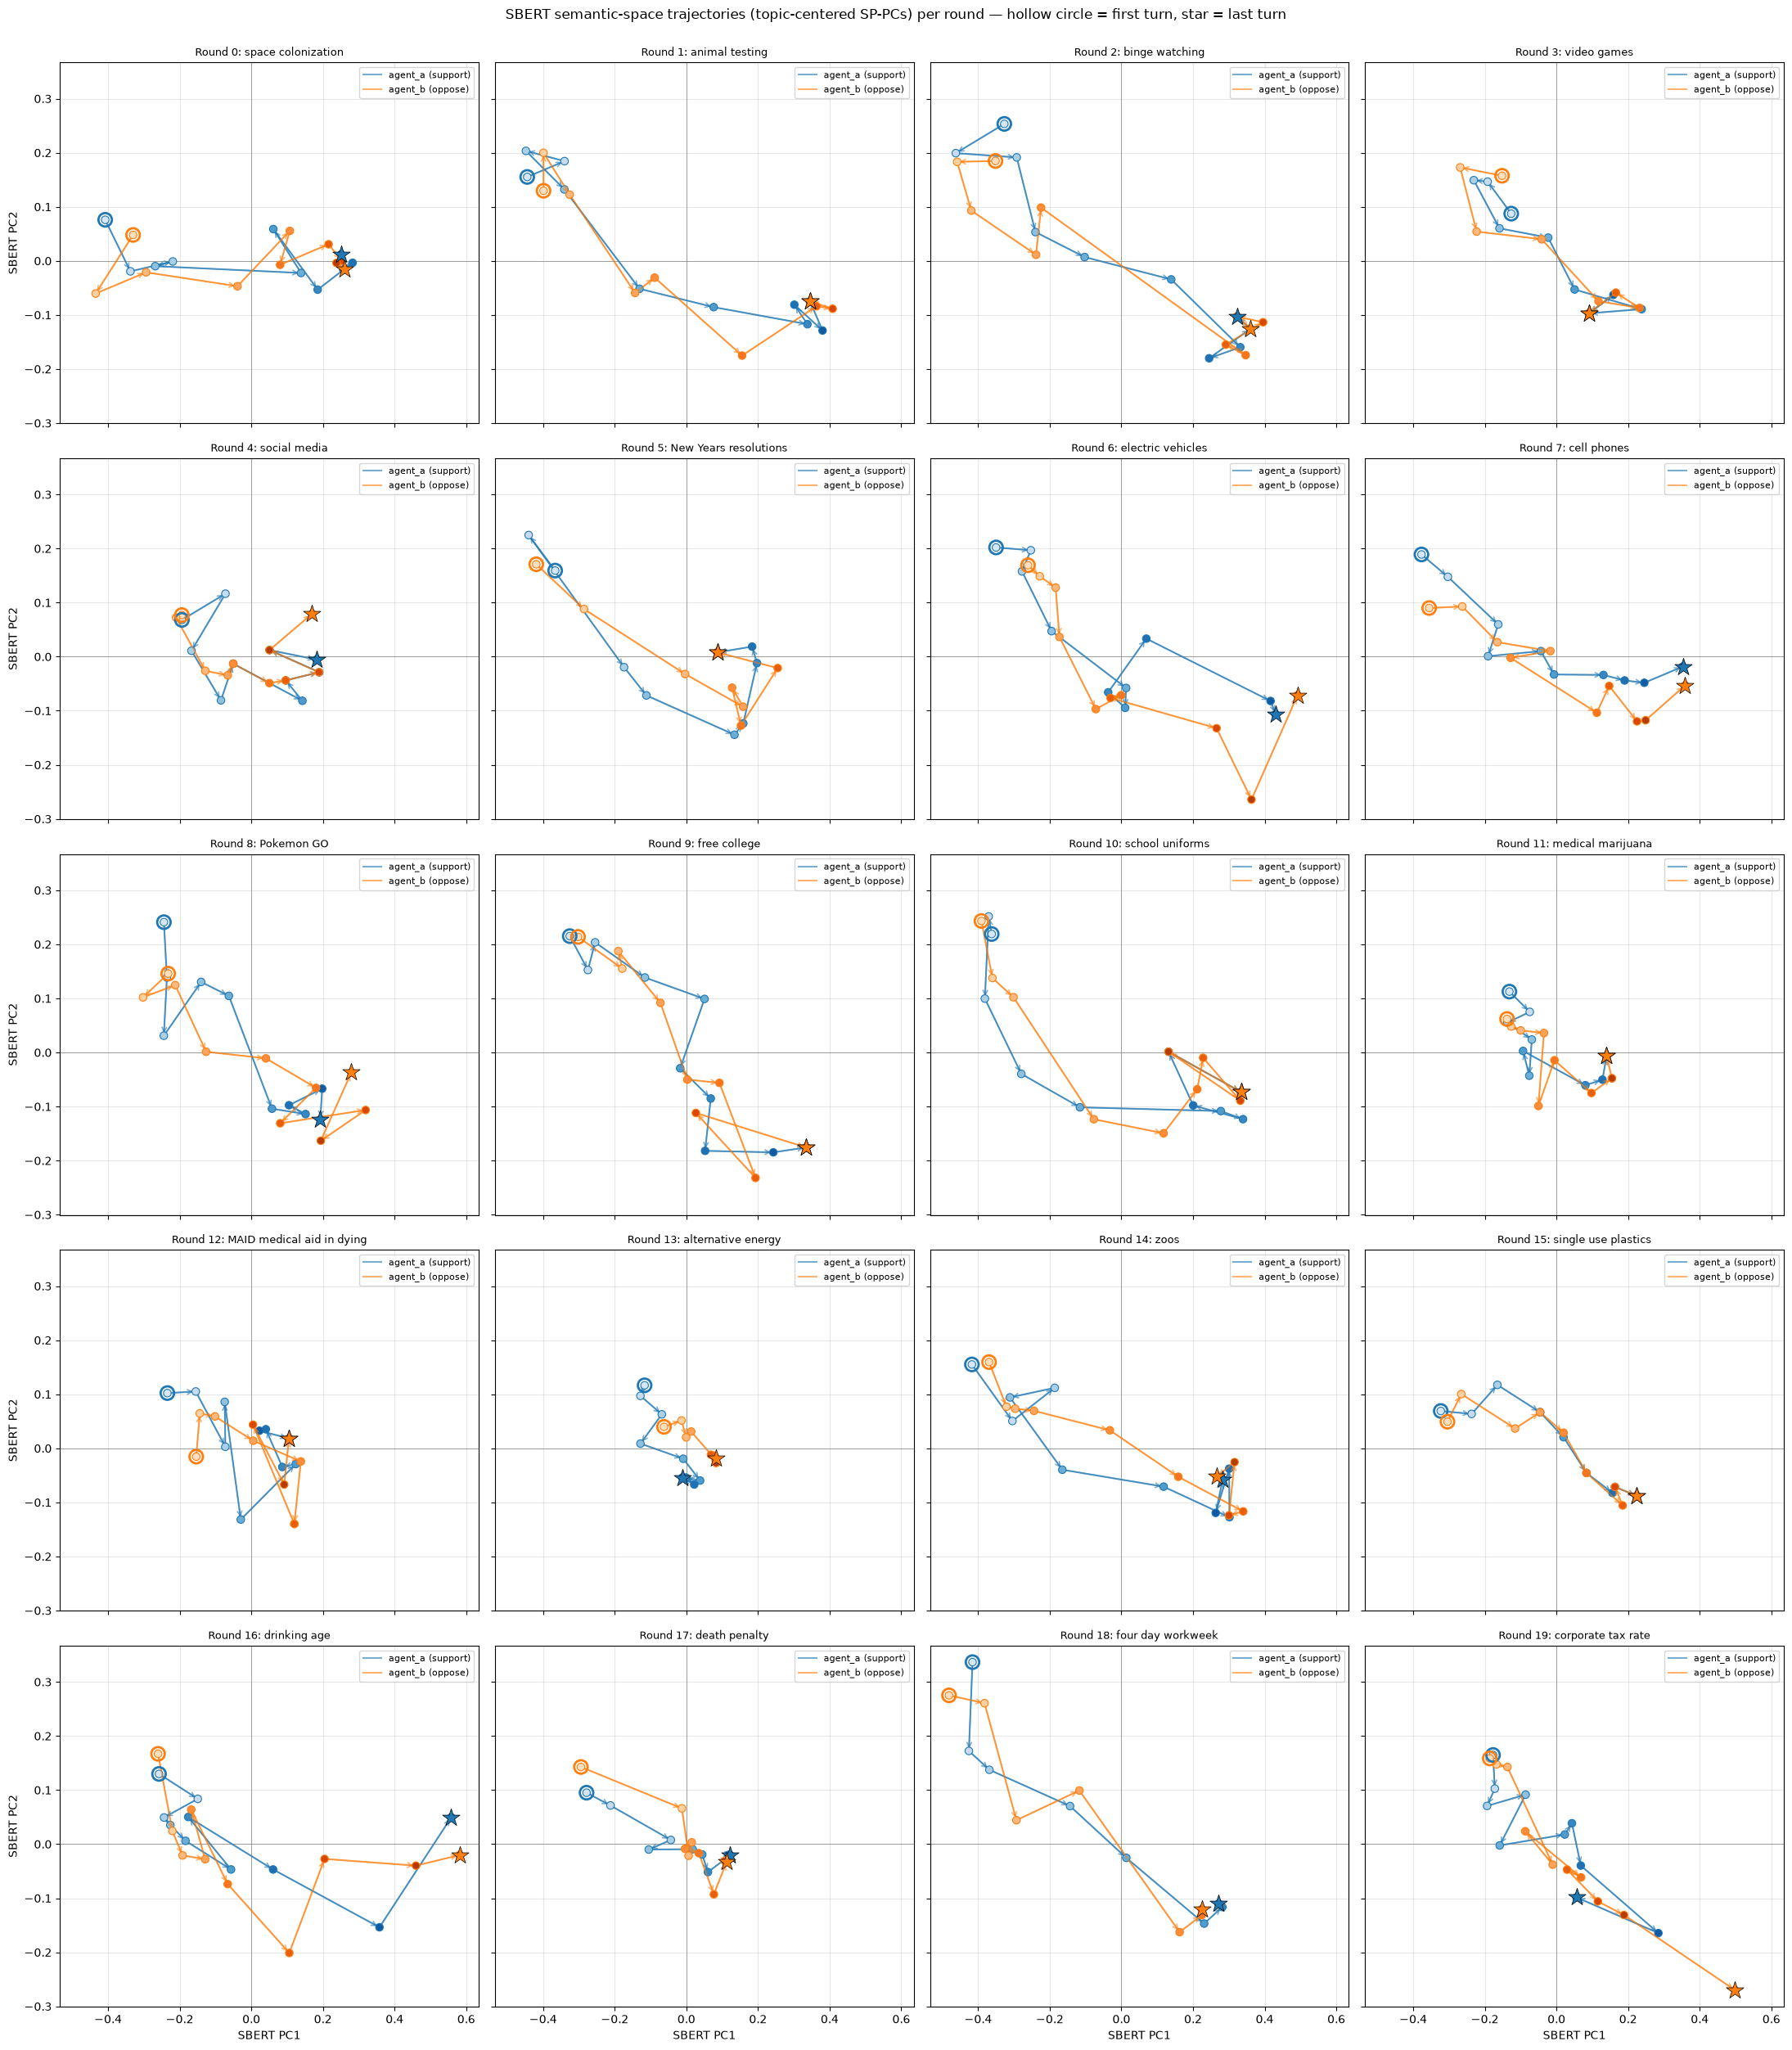

In [95]:
df = pd.read_json(Path(RUN_DIR) / "records_sbert.jsonl", lines=True)
df["round_id"] = df["round_id"].astype(str)
 
STANCE = {"agent_a": "support", "agent_b": "oppose"}
COLOR = {"agent_a": "tab:blue", "agent_b": "tab:orange"}
CMAP = {"agent_a": "Blues", "agent_b": "Oranges"}
 
rounds = sorted(df["round_id"].unique(), key=lambda r: int(r))
ncols = min(4, len(rounds))
nrows = -(-len(rounds) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows),
                         sharex=True, sharey=True, squeeze=False)
 
for ax, rnd in zip(axes.flat, rounds):
    sub = df[df["round_id"] == rnd]
    for speaker, grp in sub.groupby("speaker"):
        grp = grp.sort_values("turn")
        c = COLOR[speaker]
        x, y = grp["sbert_pc1"].values, grp["sbert_pc2"].values
 
        ax.plot(x, y, color=c, alpha=0.6, lw=1.5,
                label=f"{speaker} ({STANCE[speaker]})", zorder=2)
        for i in range(len(x) - 1):
            ax.annotate("", xy=(x[i + 1], y[i + 1]), xytext=(x[i], y[i]),
                        arrowprops=dict(arrowstyle="->", color=c, alpha=0.6, lw=1.2))
        ax.scatter(x, y, c=grp["turn"], cmap=CMAP[speaker],
                   vmin=-2, vmax=grp["turn"].max() + 1,
                   s=45, edgecolors=c, linewidths=0.8, zorder=3)
        ax.scatter(x[0], y[0], marker="o", s=140, facecolors="none",
                   edgecolors=c, linewidths=2, zorder=4)
        ax.scatter(x[-1], y[-1], marker="*", s=260, color=c,
                   edgecolors="k", linewidths=0.5, zorder=4)
 
    ax.set_title(f"Round {rnd}: {sub['topic'].iloc[0][:60]}", fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
 
for ax in axes.flat[len(rounds):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("SBERT PC1")
for row in axes:
    row[0].set_ylabel("SBERT PC2")
 
fig.suptitle("SBERT semantic-space trajectories (topic-centered SP-PCs) per round — "
             "hollow circle = first turn, star = last turn", y=1.0)
plt.tight_layout()
plt.show()


IndexError: single positional indexer is out-of-bounds

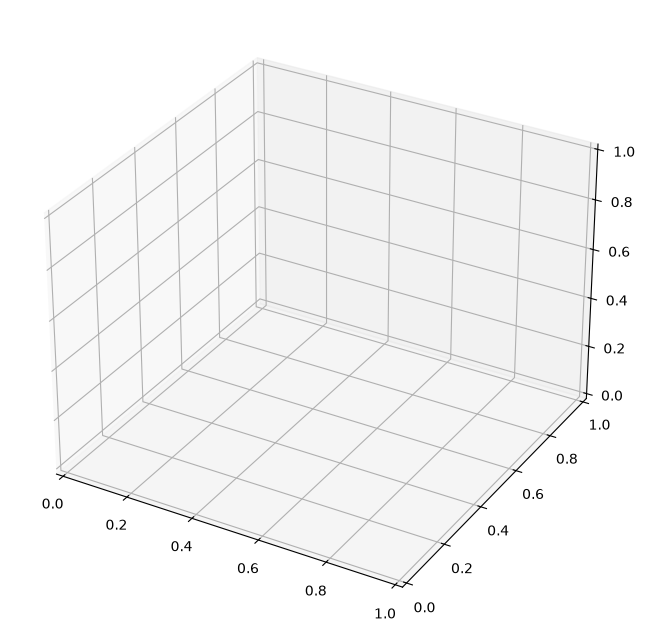

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

MODEL = "qwen"      # or "gemma"
ROUND_ID = "0"     # round_id is stored as a string in df

sub = df[(df["model"] == MODEL) & (df["round_id"] == str(ROUND_ID))]

STANCE = {"agent_a": "support", "agent_b": "oppose"}
COLOR  = {"agent_a": "tab:blue", "agent_b": "tab:orange"}
CMAP   = {"agent_a": "Blues", "agent_b": "Oranges"}

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

for speaker, grp in sub.groupby("speaker"):
    grp = grp.sort_values("turn")
    x, y, z = grp["sbert_pc1"].values, grp["sbert_pc2"].values, grp["sbert_pc3"].values
    c = COLOR[speaker]

    ax.plot(x, y, z, color=c, alpha=0.6, lw=1.5,
            label=f"{speaker} ({STANCE[speaker]})", zorder=2)
    ax.scatter(x, y, z, c=grp["turn"], cmap=CMAP[speaker],
               vmin=-2, vmax=grp["turn"].max() + 1,
               s=60, edgecolors=c, linewidths=0.8, zorder=3)
    ax.scatter(x[0], y[0], z[0], marker="o", s=180, facecolors="none",
               edgecolors=c, linewidths=2, zorder=4)
    ax.scatter(x[-1], y[-1], z[-1], marker="*", s=320, color=c,
               edgecolors="k", linewidths=0.5, zorder=4)

topic = sub["topic"].iloc[0]
ax.set_title(f"{MODEL} — Round {ROUND_ID}: {topic[:70]}", fontsize=10)
ax.set_xlabel("SBERT PC1")
ax.set_ylabel("SBERT PC2")
ax.set_zlabel("SBERT PC3")
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.show()


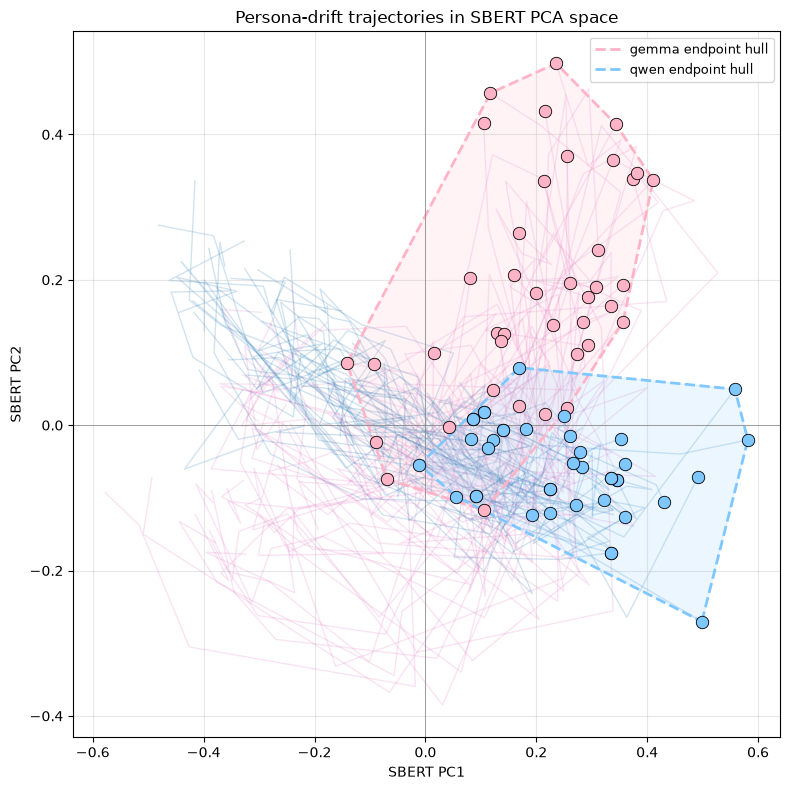

In [ ]:
from scipy.spatial import ConvexHull

MODEL_COLOR = {"qwen": "#7fc7ff", "gemma": "#ffb3c6"}   # light blue / light pink (endpoints)
TRAJ_COLOR  = {"qwen": "tab:blue", "gemma": "tab:pink"}  # trajectory lines

fig, ax = plt.subplots(figsize=(8, 8))

endpoints = []  # (x, y, model) for hull computation

for (model, rnd, speaker), grp in df.groupby(["model", "round_id", "speaker"]):
    grp = grp.sort_values("turn")
    x, y = grp["sbert_pc1"].values, grp["sbert_pc2"].values

    ax.plot(x, y, color=TRAJ_COLOR[model], alpha=0.2, lw=1, zorder=1)

    ax.scatter(x[-1], y[-1], color=MODEL_COLOR[model], s=80,
               edgecolors="k", linewidths=0.6, zorder=3)
    endpoints.append((x[-1], y[-1], model))

endpoints = pd.DataFrame(endpoints, columns=["x", "y", "model"])

for model, sub in endpoints.groupby("model"):
    pts = sub[["x", "y"]].values
    if len(pts) >= 3:
        hull = ConvexHull(pts)
        hull_pts = np.vstack([pts[hull.vertices], pts[hull.vertices[0]]])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1], color=MODEL_COLOR[model],
                lw=2, linestyle="--", label=f"{model} endpoint hull")
        ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=MODEL_COLOR[model], alpha=0.15)

ax.set_xlabel("SBERT PC1")
ax.set_ylabel("SBERT PC2")
ax.set_title("Persona-drift trajectories in SBERT PCA space")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.legend(fontsize=9, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


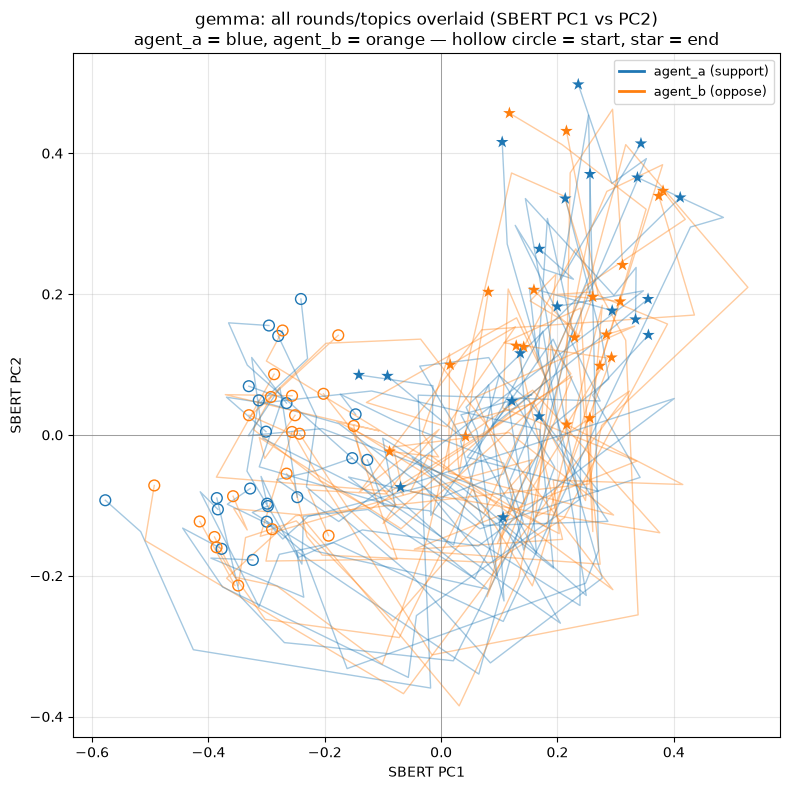

In [53]:
MODEL = "gemma"  # or "gemma"

sub_model = df[df["model"] == MODEL]

STANCE = {"agent_a": "support", "agent_b": "oppose"}
COLOR  = {"agent_a": "tab:blue", "agent_b": "tab:orange"}

fig, ax = plt.subplots(figsize=(8, 8))

for (rnd, speaker), grp in sub_model.groupby(["round_id", "speaker"]):
    grp = grp.sort_values("turn")
    x, y = grp["sbert_pc1"].values, grp["sbert_pc2"].values
    c = COLOR[speaker]

    ax.plot(x, y, color=c, alpha=0.4, lw=1, zorder=1)
    ax.scatter(x[0], y[0], marker="o", s=60, facecolors="none",
               edgecolors=c, linewidths=1, alpha=1, zorder=2)
    ax.scatter(x[-1], y[-1], marker="*", s=90, color=c,
               alpha=1, edgecolors="none", zorder=2)

# legend proxies since per-trajectory labels would repeat 20x
from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], color=COLOR["agent_a"], lw=2, label=f"agent_a ({STANCE['agent_a']})"),
                Line2D([0], [0], color=COLOR["agent_b"], lw=2, label=f"agent_b ({STANCE['agent_b']})")]
ax.legend(handles=legend_elems, fontsize=9, loc="best")

ax.set_xlabel("SBERT PC1")
ax.set_ylabel("SBERT PC2")
ax.set_title(f"{MODEL}: all rounds/topics overlaid (SBERT PC1 vs PC2)\n"
             "agent_a = blue, agent_b = orange — hollow circle = start, star = end")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
